Folder empty. Downloading public sample dataset...
Fetching boat1.jpg...
Fetching boat2.jpg...
Fetching boat3.jpg...
Fetching boat4.jpg...
Fetching boat5.jpg...
Fetching boat6.jpg...
Download complete!

Loaded: boat1.jpg  shape: (2592, 3888, 3)
Loaded: boat2.jpg  shape: (2592, 3888, 3)
Loaded: boat3.jpg  shape: (2592, 3888, 3)
Loaded: boat4.jpg  shape: (2592, 3888, 3)
Loaded: boat5.jpg  shape: (2592, 3888, 3)
Loaded: boat6.jpg  shape: (2592, 3888, 3)


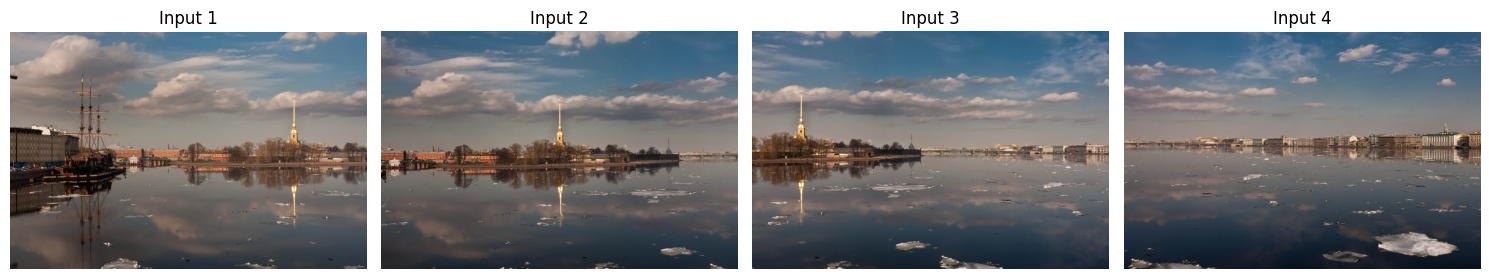


Applying cylindrical projection to all images...

Running advanced sequential stitching (Warping + Alpha Blending)...
Stitching image 1 to panorama...
Stitching image 2 to panorama...
Stitching image 3 to panorama...
Stitching image 4 to panorama...
Stitching image 5 to panorama...


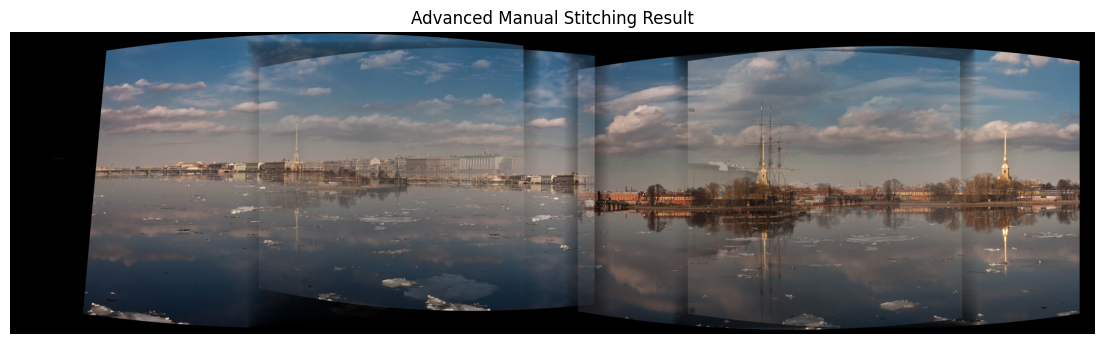


Running OpenCV Stitcher (PANORAMA mode) for comparison...


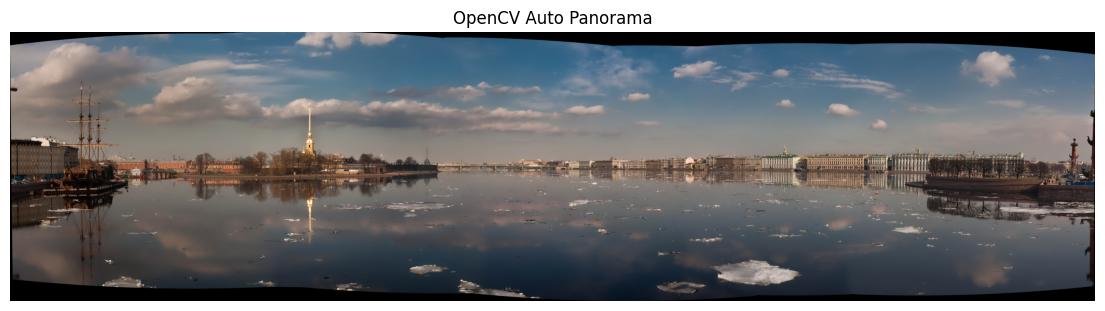

In [1]:
# =============================================================================
# Lab: Image Stitching and Panorama Creation
# Objective: Build panorama from overlapping photos using classical CV methods
# Features included:
#   • Automatic Dataset Downloader (OpenCV Boat Sequence)
#   • Cylindrical Warping (with float32 fix for cv2.remap)
#   • ORB Feature Detection + Homography (RANSAC)
#   • Distance-Transform Alpha Blending (Feathering)
#   • OpenCV Built-in Stitcher comparison
# =============================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
import os
from pathlib import Path
import urllib.request

# ────────────────────────────────────────────────
# 0. Configuration & Helper Functions
# ────────────────────────────────────────────────

IMAGE_FOLDER = "images/panorama_set"
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

def load_images(folder: str) -> List[np.ndarray]:
    """Load all images from folder. Resizes slightly to speed up processing."""
    images = []
    for file in sorted(os.listdir(folder)):
        if Path(file).suffix.lower() in IMAGE_EXTENSIONS:
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path)
            if img is not None:
                # Optional: Resize images to process faster (boat images are huge)
                # img = cv2.resize(img, (0,0), fx=0.3, fy=0.3)
                images.append(img)
                print(f"Loaded: {file}  shape: {img.shape}")
    return images

def show_images(images: List[np.ndarray], titles: List[str] = None, figsize=(15, 6)):
    """Display multiple images side by side"""
    n = len(images)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(1, n, i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(titles[i] if titles and i < len(titles) else f"Image {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# ────────────────────────────────────────────────
# 1. Advanced Processing Functions
# ────────────────────────────────────────────────

def warp_cylindrical(img: np.ndarray, focal_length: float = None) -> np.ndarray:
    """Warps an image into cylindrical coordinates to prevent edge stretching."""
    h, w = img.shape[:2]

    if focal_length is None:
        focal_length = w  # Approximation if focal length is unknown

    # Ensure the K matrix is explicitly float32
    K = np.array([[focal_length, 0, w / 2],
                  [0, focal_length, h / 2],
                  [0, 0, 1]], dtype=np.float32)

    y_idx, x_idx = np.indices((h, w), dtype=np.float32)
    x_centered = x_idx - K[0, 2]
    y_centered = y_idx - K[1, 2]

    theta = x_centered / K[0, 0]

    # Calculate source coordinates and forcefully cast back down to 32-bit floats
    x_src = (K[0, 0] * np.tan(theta) + K[0, 2]).astype(np.float32)
    y_src = (y_centered / np.cos(theta) + K[1, 2]).astype(np.float32)

    # cv2.remap requires float32 coordinate maps
    warped_img = cv2.remap(img, x_src, y_src, cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    return warped_img

def detect_and_match_features(img1: np.ndarray, img2: np.ndarray):
    """Detect ORB features and match between two images"""
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(nfeatures=2000)

    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    # BFMatcher + ratio test
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    return kp1, des1, kp2, des2, good_matches

def compute_homography(kp1, kp2, good_matches, min_matches=10):
    """Estimate homography using RANSAC"""
    if len(good_matches) < min_matches:
        return None, None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    return H, mask

def advanced_stitch_two_images(img1: np.ndarray, img2: np.ndarray, H: np.ndarray):
    """Warp img2 to img1 coordinate frame with Distance-Transform Alpha Blending."""
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)
    warped_corners = cv2.perspectiveTransform(corners_img2, H)

    corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
    all_corners = np.concatenate((corners_img1, warped_corners), axis=0)

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    t = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=np.float32)
    warp_H = t.dot(H)
    out_size = (xmax - xmin, ymax - ymin)

    result_img2 = cv2.warpPerspective(img2, warp_H, out_size)
    mask2 = np.ones((h2, w2), dtype=np.uint8) * 255
    mask2_warped = cv2.warpPerspective(mask2, warp_H, out_size)

    result_img1 = np.zeros_like(result_img2)
    result_img1[-ymin:h1 - ymin, -xmin:w1 - xmin] = img1

    mask1 = np.zeros(out_size[::-1], dtype=np.uint8)
    mask1[-ymin:h1 - ymin, -xmin:w1 - xmin] = 255

    dist1 = cv2.distanceTransform(mask1, cv2.DIST_L2, 3)
    dist2 = cv2.distanceTransform(mask2_warped, cv2.DIST_L2, 3)

    weight_sum = dist1 + dist2
    weight_sum[weight_sum == 0] = 1e-5

    alpha1 = dist1 / weight_sum
    alpha2 = dist2 / weight_sum

    blended = result_img1 * alpha1[:, :, np.newaxis] + result_img2 * alpha2[:, :, np.newaxis]
    return blended.astype(np.uint8)

def simple_stitch_all(images: List[np.ndarray]):
    """Sequentially stitch list of images"""
    panorama = images[0].copy()

    for i in range(1, len(images)):
        print(f"Stitching image {i} to panorama...")
        kp1, des1, kp2, des2, good = detect_and_match_features(panorama, images[i])

        if len(good) < 10:
            print(f"Not enough matches between {i-1} and {i}")
            continue

        H, mask = compute_homography(kp1, kp2, good)
        if H is None:
            print("Homography estimation failed")
            continue

        panorama = advanced_stitch_two_images(panorama, images[i], H)

    return panorama

# ────────────────────────────────────────────────
# 2. Execution Pipeline
# ────────────────────────────────────────────────

if __name__ == "__main__":

    # 1. Create the directory if it doesn't exist
    os.makedirs(IMAGE_FOLDER, exist_ok=True)

    # 2. If the folder is empty, download the OpenCV public 'boat' sequence
    if not os.listdir(IMAGE_FOLDER):
        print("Folder empty. Downloading public sample dataset...")
        base_url = "https://raw.githubusercontent.com/opencv/opencv_extra/4.x/testdata/stitching/boat{}.jpg"
        for i in range(1, 7):
            print(f"Fetching boat{i}.jpg...")
            urllib.request.urlretrieve(base_url.format(i), os.path.join(IMAGE_FOLDER, f"boat{i}.jpg"))
        print("Download complete!\n")

    # Load Images
    images = load_images(IMAGE_FOLDER)

    if len(images) < 2:
        print("Need at least 2 images to stitch. Please check your IMAGE_FOLDER path.")
    else:
        # Note: The original boat images are 2592x3888. This will take a moment to process!
        show_images(images[:4], titles=[f"Input {i+1}" for i in range(min(4, len(images)))])

        # Apply Cylindrical Warping FIRST
        print("\nApplying cylindrical projection to all images...")
        cylindrical_images = [warp_cylindrical(img) for img in images]

        # Run Advanced Manual Stitching
        print("\nRunning advanced sequential stitching (Warping + Alpha Blending)...")
        manual_panorama = simple_stitch_all(cylindrical_images)

        plt.figure(figsize=(14, 8))
        plt.imshow(cv2.cvtColor(manual_panorama, cv2.COLOR_BGR2RGB))
        plt.title("Advanced Manual Stitching Result")
        plt.axis('off')
        plt.show()

        # Compare with OpenCV Built-in Stitcher
        print("\nRunning OpenCV Stitcher (PANORAMA mode) for comparison...")
        stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
        status, pano = stitcher.stitch(images)

        if status == cv2.Stitcher_OK:
            plt.figure(figsize=(14, 8))
            plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
            plt.title("OpenCV Auto Panorama")
            plt.axis('off')
            plt.show()
        else:
            print(f"OpenCV Stitching failed. Status code: {status}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 107.8 MB/s eta 0:00:00
Setting up DL Pipeline on cuda...
Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:02<00:00, 16.1MB/s]



Applying Cylindrical Warp to Inputs...

Starting Deep Feature Matching...
Matching Deep Features: Image 2 to Image 1...
 -> Found 2285 deep matches.
Matching Deep Features: Image 3 to Image 2...
 -> Found 2007 deep matches.

Generating final panorama...
Cleaning up final output...


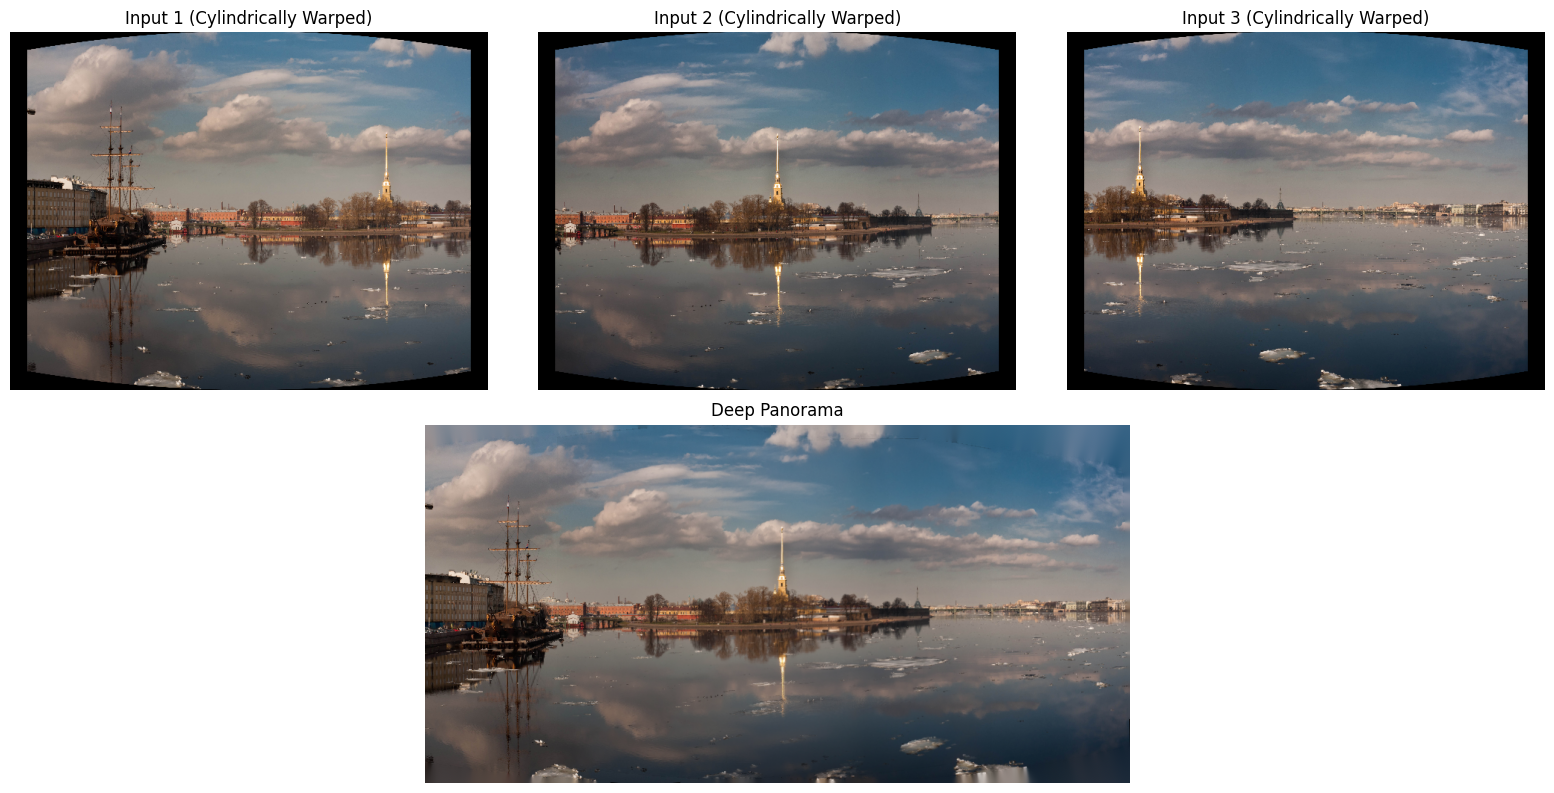

In [3]:
import sys
!{sys.executable} -m pip install kornia
# =============================================================================
# Paradigm 3.1: The Corrected Ultimate Deep Cylindrical Stitcher
# Characteristics: Cylindrical Pre-Warping, LoFTR Deep Matching,
# Dynamic Alpha Blending, and Bounding Box Inpainting.
# Requires: PyTorch and Kornia
# =============================================================================

import torch
import kornia
import kornia.feature as KF
import cv2
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# 1. Advanced Helper Functions
# ────────────────────────────────────────────────
def download_sample_images(num_images=3, folder="images/deep_stitch"):
    os.makedirs(folder, exist_ok=True)
    paths = []
    base_url = "https://raw.githubusercontent.com/opencv/opencv_extra/4.x/testdata/stitching/boat{}.jpg"
    for i in range(1, num_images + 1):
        path = os.path.join(folder, f"boat{i}.jpg")
        if not os.path.exists(path):
            print(f"Downloading boat{i}.jpg...")
            urllib.request.urlretrieve(base_url.format(i), path)
        paths.append(path)
    return paths

def warp_cylindrical(img: np.ndarray, focal_length: float = None) -> np.ndarray:
    """Warps an image into cylindrical coordinates to prevent the 'bow-tie' stretch."""
    h, w = img.shape[:2]
    if focal_length is None:
        focal_length = w

    K = np.array([[focal_length, 0, w / 2],
                  [0, focal_length, h / 2],
                  [0, 0, 1]], dtype=np.float32)

    y_idx, x_idx = np.indices((h, w), dtype=np.float32)
    x_centered = x_idx - K[0, 2]
    y_centered = y_idx - K[1, 2]

    theta = x_centered / K[0, 0]

    x_src = (K[0, 0] * np.tan(theta) + K[0, 2]).astype(np.float32)
    y_src = (y_centered / np.cos(theta) + K[1, 2]).astype(np.float32)

    warped_img = cv2.remap(img, x_src, y_src, cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    return warped_img

def preprocess_for_loftr(img_bgr, target_size=(640, 480), device='cpu'):
    img_resized = cv2.resize(img_bgr, target_size)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    tensor = kornia.image_to_tensor(img_gray, keepdim=False).float() / 255.0
    return tensor.to(device), img_resized

def clean_panorama(image):
    """
    1. Crops out the massive empty black canvas safely.
    2. Uses mild inpainting to fill the gentle curved edges of the cylindrical warp.
    """
    print("Cleaning up final output...")
    # 1. Safe Bounding Box Crop
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        image = image[y:y+h, x:x+w]

    # 2. Inpaint the remaining black curves
    gray_cropped = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray_cropped, 1, 255, cv2.THRESH_BINARY_INV)

    # Dilate mask slightly to prevent harsh edge seams during inpainting
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)

    inpainted = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)
    return inpainted

def build_multi_panorama(images_bgr, global_homographies):
    h, w = images_bgr[0].shape[:2]

    min_x, min_y = float('inf'), float('inf')
    max_x, max_y = float('-inf'), float('-inf')

    for H in global_homographies:
        corners = np.float32([[0, 0], [0, h], [w, h], [w, 0]]).reshape(-1, 1, 2)
        warped_corners = cv2.perspectiveTransform(corners, H)
        min_x = min(min_x, warped_corners[:,0,0].min())
        min_y = min(min_y, warped_corners[:,0,1].min())
        max_x = max(max_x, warped_corners[:,0,0].max())
        max_y = max(max_y, warped_corners[:,0,1].max())

    [xmin, ymin] = np.int32([min_x - 0.5, min_y - 0.5])
    [xmax, ymax] = np.int32([max_x + 0.5, max_y + 0.5])

    t = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=np.float32)
    out_size = (xmax - xmin, ymax - ymin)

    panorama = np.zeros((out_size[1], out_size[0], 3), dtype=np.float32)
    weight_map = np.zeros((out_size[1], out_size[0]), dtype=np.float32)

    for img, H in zip(images_bgr, global_homographies):
        warp_H = t.dot(H)
        warped_img = cv2.warpPerspective(img, warp_H, out_size).astype(np.float32)

        # THE FIX: Create a dynamic mask based only on the real image pixels
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, valid_pixel_mask = cv2.threshold(gray_img, 1, 255, cv2.THRESH_BINARY)

        warped_mask = cv2.warpPerspective(valid_pixel_mask, warp_H, out_size)
        dist = cv2.distanceTransform(warped_mask, cv2.DIST_L2, 3)

        panorama += warped_img * dist[:, :, np.newaxis]
        weight_map += dist

    weight_map[weight_map == 0] = 1e-5
    panorama /= weight_map[:, :, np.newaxis]

    return clean_panorama(panorama.astype(np.uint8))

# ────────────────────────────────────────────────
# 2. Execution Pipeline
# ────────────────────────────────────────────────
def run_ultimate_stitcher():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Setting up DL Pipeline on {device}...")

    matcher = KF.LoFTR(pretrained='outdoor').to(device)
    image_paths = download_sample_images(num_images=3)

    tensors = []
    bgr_images = []
    print("\nApplying Cylindrical Warp to Inputs...")
    for path in image_paths:
        img_raw = cv2.imread(path)
        img_cylindrical = warp_cylindrical(img_raw)

        t, bgr = preprocess_for_loftr(img_cylindrical, target_size=(640, 480), device=device)
        tensors.append(t)
        bgr_images.append(bgr)

    global_homographies = [np.eye(3, dtype=np.float32)]
    accumulated_H = np.eye(3, dtype=np.float32)

    print("\nStarting Deep Feature Matching...")
    for i in range(len(tensors) - 1):
        print(f"Matching Deep Features: Image {i+2} to Image {i+1}...")

        input_dict = {"image0": tensors[i], "image1": tensors[i+1]}

        with torch.no_grad():
            correspondences = matcher(input_dict)

        mkpts0 = correspondences['keypoints0'].cpu().numpy()
        mkpts1 = correspondences['keypoints1'].cpu().numpy()

        H_local, mask = cv2.findHomography(mkpts1, mkpts0, cv2.USAC_MAGSAC, 5.0)

        if H_local is not None:
            accumulated_H = accumulated_H @ H_local.astype(np.float32)
            global_homographies.append(accumulated_H)
            print(f" -> Found {len(mkpts0)} deep matches.")
        else:
            print(f" -> Failed to find robust homography.")
            return

    print("\nGenerating final panorama...")
    final_panorama = build_multi_panorama(bgr_images, global_homographies)

    # Plotting
    plt.figure(figsize=(16, 8))
    for i, img in enumerate(bgr_images):
        plt.subplot(2, len(bgr_images), i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Input {i+1} (Cylindrically Warped)")
        plt.axis('off')

    plt.subplot(2, 1, 2)
    plt.imshow(cv2.cvtColor(final_panorama, cv2.COLOR_BGR2RGB))
    plt.title("Deep Panorama")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_ultimate_stitcher()
